# Effective binding × frequency analysis

This notebook reads the effective-binding CSVs. It does **not** load a language
model. It reproduces the late-layer frequency test with raw attention and with
norm-aware binding, saves tables, and selects candidate heads using only half of
the compounds.


In [11]:
# Cell 1b: Environment check after session restart
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
print(f"Environment: {'Colab' if IN_COLAB else 'Local'}")

Environment: Local


In [12]:
# Cell 2: Project Root & Path Setup
if IN_COLAB:
    from google.colab import userdata
    token = userdata.get("GH_TMLR")

    repo_owner = "trishasalas"
    repo_name = "tmlr"
    repo_url = f"https://{token}@github.com/{repo_owner}/{repo_name}.git"

    PROJECT_ROOT = Path("/content") / repo_name

    if not PROJECT_ROOT.exists():
        !git clone {repo_url} {PROJECT_ROOT}
else:
    # Local: notebook lives in notebooks/, project root is one level up
    PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/trishasalas/Repos/Research/tmlr


In [13]:
# Cell 0a: Colab-only analysis dependencies
if IN_COLAB:
    %pip install -q pandas scipy matplotlib


In [19]:
# Cell 1: Imports
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from IPython.display import display

CONDITION = "uniform"   # run once as natural, then once as uniform
N_BOOTSTRAPS = 2000
RANDOM_SEED = 42

assert CONDITION in {"natural", "uniform"}

output_dir = PROJECT_ROOT / "results" / "analysis"
figure_dir = PROJECT_ROOT / "results" / "analysis" / "figures"
output_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)


## Load and validate the CSVs

The error messages in this cell are intentional: if a model run is incomplete,
the notebook stops rather than silently analyzing a partial file.


In [20]:
files = sorted(
    (PROJECT_ROOT / "results" / "effective_binding").glob(
        f"*/*/{CONDITION}/*-{CONDITION}-accessibility.csv"
    )
)

if not files:
    raise FileNotFoundError(
        f"No {CONDITION!r} effective-binding files found. "
        "Run an effective-binding model notebook first."
    )

required = {
    "compound", "layer", "head", "attention_weight",
    "weighted_ov_norm", "relative_weighted_ov_norm", "model",
}

frames = []
for path in files:
    frame = pd.read_csv(path)
    missing = required - set(frame.columns)
    if missing:
        raise ValueError(f"{path.name} is missing columns: {sorted(missing)}")
    frame["family"] = path.parts[-4]
    frames.append(frame)
    print(f"✓ {path.parts[-4]:7s} {frame['model'].iloc[0]:22s} {len(frame):,} rows")

detailed = pd.concat(frames, ignore_index=True)
print(f"\nLoaded {len(detailed):,} rows from {len(files)} models.")


✓ gpt2    gpt2                   7,632 rows
✓ gpt2    gpt2-large             38,160 rows
✓ gpt2    gpt2-medium            20,352 rows
✓ gpt2    gpt2-xl                63,600 rows
✓ olmo    OLMo-2-0425-1B         13,568 rows
✓ olmo    OLMo-2-1124-13B        84,800 rows
✓ olmo    OLMo-2-1124-7B         54,272 rows
✓ pythia  pythia-12b             76,320 rows
✓ pythia  pythia-160m            7,632 rows
✓ pythia  pythia-1b              6,784 rows
✓ pythia  pythia-2.8b            54,272 rows
✓ pythia  pythia-410m            20,352 rows
✓ pythia  pythia-6.9b            54,272 rows

Loaded 502,016 rows from 13 models.


## Summarize the final third

`max_attention` directly reproduces the old measurement. The other summaries
ask whether the same pattern survives after incorporating the value/OV write.
The 95th percentile and top-five mean are less dependent on one extreme head.


In [21]:
def top_five_mean(values):
    return values.nlargest(min(5, len(values))).mean()


# Infer each model's depth from its saved layer numbers.
detailed["n_layers"] = detailed.groupby(
    ["family", "model"]
)["layer"].transform("max") + 1
detailed["first_late_layer"] = np.ceil(
    detailed["n_layers"] * 2 / 3
).astype(int)

late = detailed[detailed["layer"] >= detailed["first_late_layer"]].copy()

summary = (
    late.groupby(["family", "model", "compound"], as_index=False)
        .agg(
            max_attention=("attention_weight", "max"),
            max_weighted=("weighted_ov_norm", "max"),
            max_relative=("relative_weighted_ov_norm", "max"),
            p95_relative=("relative_weighted_ov_norm", lambda x: x.quantile(.95)),
            mean_top5_relative=("relative_weighted_ov_norm", top_five_mean),
        )
)

frequency = pd.read_csv(PROJECT_ROOT / "results" / "frequency" / "frequency_table.csv")
frequency = frequency[["compound", "bigram_count"]].drop_duplicates("compound")
summary = summary.merge(frequency, on="compound", how="inner", validate="many_to_one")
summary["log_frequency"] = np.log1p(summary["bigram_count"])

counts = summary.groupby(["family", "model"])["compound"].nunique()
if (counts < 40).any():
    raise ValueError(f"Too few matched compounds in one or more models:\n{counts}")

summary_path = output_dir / f"effective_binding_compound_summary_{CONDITION}.csv"
summary.to_csv(summary_path, index=False)
print(f"Saved: {summary_path}")
display(summary.head())


Saved: /Users/trishasalas/Repos/Research/tmlr/results/analysis/effective_binding_compound_summary_uniform.csv


,family,model,compound,max_attention,max_weighted,max_relative,p95_relative,mean_top5_relative,bigram_count,log_frequency
0,gpt2,gpt2,accessibility_tree,0.564373,130.807266,0.562314,0.042737,0.159651,1307,7.176255
1,gpt2,gpt2-large,accessibility_tree,0.647680,67.414474,0.226552,0.013774,0.121952,1307,7.176255
2,gpt2,gpt2-medium,accessibility_tree,0.872946,63.054760,0.095404,0.014077,0.042039,1307,7.176255
3,gpt2,gpt2-xl,accessibility_tree,0.910342,14.986053,0.044359,0.007568,0.027495,1307,7.176255
4,olmo,OLMo-2-0425-1B,accessibility_tree,0.620907,4.694778,0.153557,0.092076,0.107556,1307,7.176255


## Model-level correlations and bootstrap intervals

The bootstrap resamples compounds, not individual heads. The important comparison
is whether the negative frequency relationship survives for norm-aware measures.


In [22]:
MEASURES = [
    "max_attention", "max_weighted", "max_relative",
    "p95_relative", "mean_top5_relative",
]


def bootstrap_spearman(x, y, n_boot=N_BOOTSTRAPS, seed=RANDOM_SEED):
    x = np.asarray(x)
    y = np.asarray(y)
    rng = np.random.default_rng(seed)
    estimates = []
    for _ in range(n_boot):
        chosen = rng.integers(0, len(x), len(x))
        rho = spearmanr(x[chosen], y[chosen]).statistic
        if np.isfinite(rho):
            estimates.append(rho)
    if not estimates:
        return np.array([np.nan, np.nan])
    return np.quantile(estimates, [.025, .975])


rows = []
for (family, model_name), group in summary.groupby(["family", "model"]):
    for measure in MEASURES:
        test = spearmanr(group["log_frequency"], group[measure])
        low, high = bootstrap_spearman(group["log_frequency"], group[measure])
        rows.append({
            "condition": CONDITION,
            "family": family,
            "model": model_name,
            "measure": measure,
            "n_compounds": len(group),
            "rho": test.statistic,
            "p_value": test.pvalue,
            "ci_low": low,
            "ci_high": high,
        })

correlations = pd.DataFrame(rows)
corr_path = output_dir / f"effective_binding_correlations_{CONDITION}.csv"
correlations.to_csv(corr_path, index=False)

display(
    correlations.pivot_table(
        index=["family", "model"], columns="measure", values="rho"
    ).round(3)
)
print(f"Saved: {corr_path}")


measure                 max_attention  max_relative  max_weighted  \
family model                                                        
gpt2   gpt2                    -0.262        -0.112        -0.183   
       gpt2-large              -0.180         0.030        -0.016   
       gpt2-medium             -0.275        -0.107        -0.047   
       gpt2-xl                 -0.263        -0.009         0.097   
olmo   OLMo-2-0425-1B          -0.497        -0.238         0.052   
       OLMo-2-1124-13B         -0.128         0.457         0.265   
       OLMo-2-1124-7B          -0.276         0.226         0.272   
pythia pythia-12b              -0.520        -0.071        -0.146   
       pythia-160m             -0.211        -0.057        -0.001   
       pythia-1b               -0.414        -0.403        -0.381   
       pythia-2.8b             -0.300        -0.324        -0.346   
       pythia-410m             -0.415        -0.455        -0.457   
       pythia-6.9b             -0.336        -0.053        -0.103   

measure                 mean_top5_relative  p95_relative  
family model                                              
gpt2   gpt2                         -0.143        -0.314  
       gpt2-large                   -0.081        -0.350  
       gpt2-medium                  -0.103        -0.342  
       gpt2-xl                      -0.163        -0.240  
olmo   OLMo-2-0425-1B               -0.397        -0.442  
       OLMo-2-1124-13B               0.222        -0.217  
       OLMo-2-1124-7B               -0.050        -0.347  
pythia pythia-12b                   -0.292        -0.452  
       pythia-160m                  -0.191        -0.266  
       pythia-1b                    -0.396        -0.310  
       pythia-2.8b                  -0.463        -0.368  
       pythia-410m                  -0.528        -0.413  
       pythia-6.9b                  -0.319        -0.352

Saved: /Users/trishasalas/Repos/Research/tmlr/results/analysis/effective_binding_correlations_uniform.csv


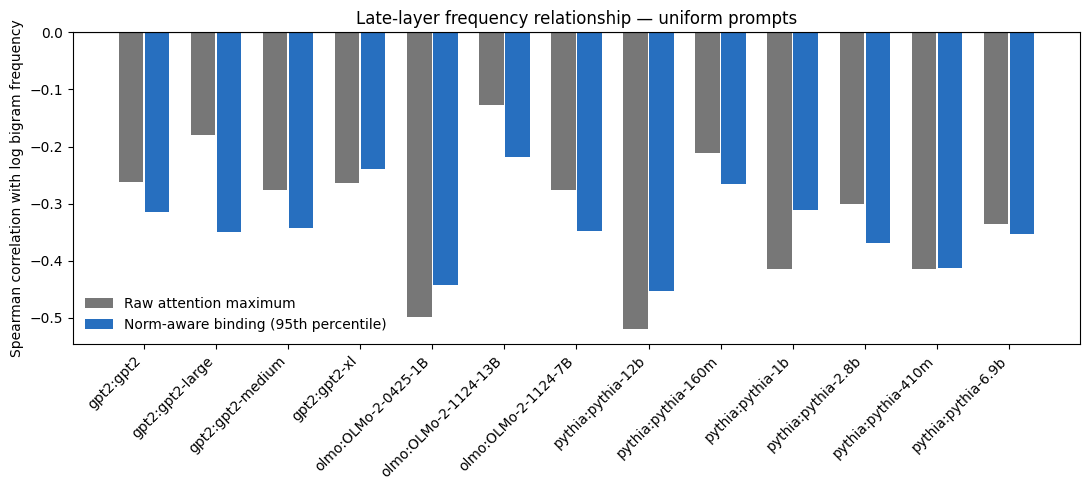

Saved: /Users/trishasalas/Repos/Research/tmlr/results/analysis/figures/effective_binding_frequency_uniform.png


In [23]:
# Figure: raw attention versus norm-aware binding
plot_data = correlations[
    correlations["measure"].isin(["max_attention", "p95_relative"])
].copy()

fig, ax = plt.subplots(figsize=(11, 5))
labels = (plot_data[["family", "model"]].drop_duplicates()
          .assign(label=lambda x: x["family"] + ":" + x["model"]))
order = labels["label"].tolist()
x = np.arange(len(order))

for offset, (measure, label, color) in zip(
    [-0.18, 0.18],
    [
        ("max_attention", "Raw attention maximum", "#777777"),
        ("p95_relative", "Norm-aware binding (95th percentile)", "#276FBF"),
    ],
):
    sub = plot_data[plot_data["measure"] == measure].copy()
    sub["label"] = sub["family"] + ":" + sub["model"]
    sub = sub.set_index("label").reindex(order)
    ax.bar(x + offset, sub["rho"], width=.34, label=label, color=color)

ax.axhline(0, color="black", linewidth=.8)
ax.set_ylabel("Spearman correlation with log bigram frequency")
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=45, ha="right")
ax.legend(frameon=False)
ax.set_title(f"Late-layer frequency relationship — {CONDITION} prompts")
fig.tight_layout()
figure_path = figure_dir / f"effective_binding_frequency_{CONDITION}.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {figure_path}")


## Select heads without looking at the test compounds

The split is made once from compound names and reused for every model. Candidate
heads are chosen using the selection half only. Their frequency relationship is
then measured on the untouched test half.


In [24]:
all_compounds = sorted(summary["compound"].unique())
rng = np.random.default_rng(RANDOM_SEED)
rng.shuffle(all_compounds)
split_point = len(all_compounds) // 2
selection_compounds = set(all_compounds[:split_point])
test_compounds = set(all_compounds[split_point:])

print(f"Selection compounds: {len(selection_compounds)}")
print(f"Test compounds:      {len(test_compounds)}")

late_with_frequency = late.merge(
    frequency, on="compound", how="inner", validate="many_to_one"
)
late_with_frequency["log_frequency"] = np.log1p(
    late_with_frequency["bigram_count"]
)


def benjamini_hochberg(p_values):
    """False-discovery-rate adjusted p-values, implemented without extra packages."""
    p = np.asarray(p_values, dtype=float)
    result = np.full(p.shape, np.nan, dtype=float)
    finite_positions = np.flatnonzero(np.isfinite(p))
    if len(finite_positions) == 0:
        return result

    # Constant-signal heads have undefined Spearman tests (NaN). Exclude only
    # those heads from the correction; otherwise one NaN contaminates every
    # adjusted p-value in the model.
    finite_p = p[finite_positions]
    order = np.argsort(finite_p)
    ranked = finite_p[order]
    adjusted = ranked * len(finite_p) / np.arange(1, len(finite_p) + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    finite_result = np.empty_like(adjusted)
    finite_result[order] = np.clip(adjusted, 0, 1)
    result[finite_positions] = finite_result
    return result


head_rows = []
test_rows = []
candidate_rows = []

for (family, model_name), model_data in late_with_frequency.groupby(["family", "model"]):
    selection = model_data[model_data["compound"].isin(selection_compounds)]
    per_head = []
    for (layer, head), group in selection.groupby(["layer", "head"]):
        test = spearmanr(group["log_frequency"], group["relative_weighted_ov_norm"])
        per_head.append({
            "condition": CONDITION, "family": family, "model": model_name,
            "layer": layer, "head": head, "selection_rho": test.statistic,
            "selection_p": test.pvalue, "n_selection": len(group),
        })

    per_head = pd.DataFrame(per_head)
    per_head["selection_p_fdr"] = benjamini_hochberg(per_head["selection_p"])
    per_head = per_head.sort_values("selection_rho")
    head_rows.append(per_head)

    candidates = per_head.head(5).copy()
    candidates["candidate_rank"] = np.arange(1, len(candidates) + 1)
    candidate_rows.append(candidates)

    pairs = list(zip(candidates["layer"].astype(int), candidates["head"].astype(int)))
    held_out = model_data[
        model_data["compound"].isin(test_compounds)
        & model_data.set_index(["layer", "head"]).index.isin(pairs)
    ]
    held_out_scores = held_out.groupby("compound", as_index=False).agg(
        candidate_head_signal=("relative_weighted_ov_norm", "mean"),
        log_frequency=("log_frequency", "first"),
    )
    test = spearmanr(
        held_out_scores["log_frequency"],
        held_out_scores["candidate_head_signal"],
    )
    test_rows.append({
        "condition": CONDITION, "family": family, "model": model_name,
        "n_test": len(held_out_scores), "held_out_rho": test.statistic,
        "held_out_p": test.pvalue,
    })

head_results = pd.concat(head_rows, ignore_index=True)
candidates = pd.concat(candidate_rows, ignore_index=True)
held_out_results = pd.DataFrame(test_rows)

head_results.to_csv(
    output_dir / f"effective_binding_all_head_correlations_{CONDITION}.csv",
    index=False,
)
candidates.to_csv(
    output_dir / f"effective_binding_head_candidates_{CONDITION}.csv",
    index=False,
)
held_out_results.to_csv(
    output_dir / f"effective_binding_head_heldout_{CONDITION}.csv",
    index=False,
)

print("Candidate heads (chosen on selection compounds only):")
display(candidates[[
    "family", "model", "candidate_rank", "layer", "head",
    "selection_rho", "selection_p_fdr",
]])
print("Held-out compound results:")
display(held_out_results)


Selection compounds: 24
Test compounds:      25
Candidate heads (chosen on selection compounds only):


/var/folders/yh/xk6gjqjx7hn5f6v0rd14jj8h0000gn/T/ipykernel_37441/3998629088.py:49: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  test = spearmanr(group["log_frequency"], group["relative_weighted_ov_norm"])
/var/folders/yh/xk6gjqjx7hn5f6v0rd14jj8h0000gn/T/ipykernel_37441/3998629088.py:49: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  test = spearmanr(group["log_frequency"], group["relative_weighted_ov_norm"])


,family,model,candidate_rank,layer,head,selection_rho,selection_p_fdr
0,gpt2,gpt2,1,10,10,-0.501739,0.446435
1,gpt2,gpt2,2,11,8,-0.433043,0.446435
2,gpt2,gpt2,3,10,9,-0.390435,0.446435
3,gpt2,gpt2,4,9,0,-0.390435,0.446435
4,gpt2,gpt2,5,11,9,-0.388696,0.446435
...,...,...,...,...,...,...,...
60,pythia,pythia-6.9b,1,22,2,-0.677391,0.065010
61,pythia,pythia-6.9b,2,25,19,-0.663478,0.065010
62,pythia,pythia-6.9b,3,22,14,-0.628696,0.106037
63,pythia,pythia-6.9b,4,25,25,-0.613913,0.112733


Held-out compound results:


,condition,family,model,n_test,held_out_rho,held_out_p
0,uniform,gpt2,gpt2,25,0.245385,0.237090
1,uniform,gpt2,gpt2-large,25,0.196923,0.345430
2,uniform,gpt2,gpt2-medium,25,-0.398462,0.048509
3,uniform,gpt2,gpt2-xl,25,0.134615,0.521167
4,uniform,olmo,OLMo-2-0425-1B,25,-0.507692,0.009577
5,uniform,olmo,OLMo-2-1124-13B,25,-0.562308,0.003437
6,uniform,olmo,OLMo-2-1124-7B,25,-0.246154,0.235576
7,uniform,pythia,pythia-12b,25,-0.270769,0.190484
8,uniform,pythia,pythia-160m,25,0.110769,0.598112
9,uniform,pythia,pythia-1b,25,0.086154,0.682189


In [ ]:
# Optional: commit only the tables and figures created by this notebook.
import os
os.chdir(PROJECT_ROOT)
!git config user.email "trisha@trishasalas.com"
!git config user.name "Trisha Salas"
!git add results/analysis/
!git commit -m "analyze effective binding and frequency: {CONDITION}"
!git push
